In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Stage 1: Exploring The Folder Structure

In [ ]:
# I am exploring my folder structure (tree structure)
import os

#Going through everything in my uploaded dataset
input_path = "/kaggle/input/datasets/prospi/dhs-anc-data"

for root, dirs, files in os.walk(input_path):
    #I will skip hidden folders here
    dirs[:] = [d for d in dirs if not d.startswith('.')]
    level = root.replace(input_path, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    for file in files:
        filepath = os.path.join(root, file)
        size_mb = os.path.getsize(filepath) / (1024 * 1024)
        print(f"  {indent}{file}  ({size_mb:.1f} MB)")

# Stage 2: Install Libraries and Preprocess

In [ ]:
# Install pyreadstat
import subprocess
subprocess.run(["pip", "install", "pyreadstat", "-q"])
print ("Done")

In [ ]:
# Here I set the exact file paths to know where to read from
import os

BASE = "/kaggle/input/datasets/prospi/dhs-anc-data/data_raw"

NIGERIA_IR = os.path.join(
    BASE,
    "/kaggle/input/datasets/prospi/dhs-anc-data/data_raw/nigeria_2024/NG_2024_DHS_02122026_1349_239942/NGIR8BDT/NGIR8BFL.dta")

KENYA_IR = os.path.join(
    BASE,
    "/kaggle/input/datasets/prospi/dhs-anc-data/data_raw/kenya_2022/KE_2022_DHS_02122026_161_239942/KEIR8CDT/KEIR8CFL.DTA")

NIGERIA_GC = os.path.join(
    BASE,
    "/kaggle/input/datasets/prospi/dhs-anc-data/data_raw/nigeria_2024/NG_2024_DHS_02122026_1349_239942/NGGC8AFL/NGGC8AFL.csv")

KENYA_GC = os.path.join(
    BASE,
    "/kaggle/input/datasets/prospi/dhs-anc-data/data_raw/kenya_2022/KE_2022_DHS_02122026_161_239942/KEGC8AFL/KEGC8AFL.csv")

# Confirm if each path resolves
for label, path in [("Nigeria IR", NIGERIA_IR), ("Kenya IR", KENYA_IR), ("Nigeria GC", NIGERIA_GC), ("Kenya GC", KENYA_GC)]:
    exists = os.path.exists(path)
    size = f"{os.path.getsize(path)/1e6:1f} MB" if exists else "NOT FOUND"
    print(f"{label:12s} {exists} {size} {path}")

In [ ]:
# Now let's check the column names without loading the full file

import pyreadstat
import warnings
warnings.filterwarnings("ignore")

def peek_columns(filepath):
    _, meta = pyreadstat.read_dta(filepath, row_limit=1)
    return [c.lower() for c in meta.column_names]

ng_cols = peek_columns(NIGERIA_IR)
ke_cols = peek_columns(KENYA_IR)

print(f"Nigeria IR columns: {len(ng_cols)}")
print(f"Kenya IR columns:   {len(ke_cols)}")

# Check every variable the chosen methodology requires
REQUIRED = [
    "m14",    # ANC visits — the outcome
    "v012",   # age
    "v106",   # education
    "v190",   # wealth quintile
    "v025",   # urban/rural
    "v024",   # region ADM1
    "v001",   # cluster ID
    "v005",   # sample weight
    "v201",   # total children
    "v218",   # living children
    "v467b",  # barrier: permission
    "v467c",  # barrier: money
    "v467d",  # barrier: distance
    "v467f",  # barrier: alone
    "v501",   # marital status
    "v730",   # partner education (often useful)
    "v102",   # region of residence alternative
    "v113",   # source of drinking water
    "v116",   # type of toilet facility
    "v161",   # type of cooking fuel
]

print("\n{:<10} {:>10} {:>10} {}".format("Variable", "Nigeria", "Kenya", "Status"))
print("-" * 45)
for var in REQUIRED:
    in_ng = var in ng_cols
    in_ke = var in ke_cols
    if in_ng and in_ke:
        status = "OK"
    elif in_ng and not in_ke:
        status = "Nigeria missing"
    else:
        status = "BOTH missing"
    print(f"{var:<10} {str(in_ng):>10} {status}")

In [ ]:
# Checked again for the type and number of columns
print(type(ng_cols))
print(type(ke_cols))

print(len(ng_cols))
print(len(ke_cols))

In [ ]:
# Printed out first 20 column names under Nigeria
print(ng_cols[:20])

In [ ]:
find_anc_variable(ng_cols, "Nigeria")

In [ ]:
KEEP_VARS = [
    "m14_1",
    "v012", "v106", "v190", "v025", "v024",
    "v001", "v005", "v201", "v218",
    "v467b", "v467c", "v467d", "v467f",
    "v501", "v730", "v113", "v116", "v161",
]

def load_ir(filepath, country_label, keep_vars, all_cols):
    load = [v for v in keep_vars if v in all_cols]
    skip = [v for v in keep_vars if v not in all_cols]
    if skip:
        print(f"[{country_label}] Skipping (not in file): {skip}")
    print(f"[{country_label}] Loading {len(load)} columns ...")
    df, _ = pyreadstat.read_dta(filepath, usecols=load, encoding="latin1")
    df.columns = df.columns.str.lower()
    df["country"] = country_label
    print(f"[{country_label}] Loaded {len(df):,} rows")
    return df

ng_raw = load_ir(NIGERIA_IR, "nigeria", KEEP_VARS, ng_cols)
ke_raw = load_ir(KENYA_IR,   "kenya",   KEEP_VARS, ke_cols)

In [ ]:
# m14 was not found in the columns
# Knowing that the IR file has one row per woman with multiple births
# I will use m14_1 as the most recent birth instead of m14
# Update KEEP_VARS to replace m14 with m14_1

KEEP_VARS = [
    "m14_1", # ANC visits for most recent birth, replaces m14
    "v012", "v106", "v190", "v025", "v024",
    "v001", "v005", "v201", "v218",
    "v467b", "v467c", "v467d", "v467f",
    "v501", "v730", "v113", "v116", "v161",
]

# Verify that both files have it
print("m14_1 in Nigeria:", "m14_1" in ng_cols)
print("m14_1 in Kenya:", "m14_1" in ke_cols)




In [ ]:
def build_outcome(df, country_label, threshold=4):
    df = df.copy()
    df = df.rename(columns={"m14_1": "m14"})
    df["m14"] = pd.to_numeric(df["m14"], errors="coerce")
    df.loc[df["m14"] >= 98, "m14"] = np.nan
    before = len(df)
    df = df.dropna(subset=["m14"]).copy()
    df["anc_adequate"] = (df["m14"] >= threshold).astype(int)
    rate = df["anc_adequate"].mean() * 100
    print(f"[{country_label}] Rows: {len(df):,} | Dropped: {before-len(df):,} | ANC adequate: {rate:.1f}%")
    return df

ng = build_outcome(ng_raw, "nigeria")
ke = build_outcome(ke_raw, "kenya")

In [ ]:
# The number of rows dropped were almost double those that remained
# Dropped rows are women who either had no recent birth or were not asked the question
# Check the retained rows make sense demographically
# Nigeria's poorest quintile (3,648) is nearly double the richest (2,050).

for df, label in [(ng, "Nigeria"), (ke, "Kenya")]:
    print(f"\n{label}")
    print(f"  Rows retained        : {len(df):,}")
    print(f"  ANC adequate rate    : {df['anc_adequate'].mean()*100:.1f}%")
    print(f"  Age range            : {df['v012'].min():.0f} – {df['v012'].max():.0f}")
    print(f"  Wealth distribution  :\n{df['v190'].value_counts().sort_index()}")
    print(f"  Urban share          : {(df['v025']==1).mean()*100:.1f}%")

In [ ]:
# Clean DHS sentinel codes
# Protected columns are not touched
# Replace missing values with NaN
# Cleaning both datasets
# Create an urban indicator

def clean_dhs(df, country_label):
    df = df.copy() # Prevents modifying the original dataset
    protected = {"m14", "anc_adequate", "country", "v001", "v005", "v024", "v025", "v190", "v106"}
    num_cols = [c for c in df.select_dtypes(include=[np.number]).columns
               if c not in protected] # Clean all variables except in protected columns
    for col in num_cols:
        col_max = df[col].max()
        if col_max in [8,9]: df.loc[df[col] >= 8, col] = np.nan
        elif col_max in [98,99]: df.loc[df[col] >= 98, col] = np.nan
        elif col_max in [998, 999]: df.loc[df[col] >= 998, col] = np.nan
    df["sample_weight"] = df["v005"] / 1_000_000 # Converts weights back to real weights
    df = df.drop(columns=["v005"]) # Replace original weight with new sample_weight
    df["urban"] = (df["v025"] == 1).astype(int)
    print(f"[{country_label}] Cleaning complete")
    return df
ng = clean_dhs(ng, "nigeria")
ke = clean_dhs(ke, "kenya")

In [ ]:
# Finding out what would be dropped
# Preview what will be dropped before running align_and_combine
ng_only = set(ng.columns) - set(ke.columns)
ke_only = set(ke.columns) - set(ng.columns)
common  = set(ng.columns) & set(ke.columns)

print(f"Shared columns (kept)        : {len(common)}")
print(f"Nigeria-only (will be dropped): {sorted(ng_only)}")
print(f"Kenya-only (will be dropped)  : {sorted(ke_only)}")

In [ ]:
# Align and combine columns
# Keeps only shared columns which is essential for horizontal federated learning

def align_and_combine(ng, ke):
    common = sorted(set(ng.columns) & set(ke.columns)) # Keeping common values in each dataset for fair comparisons
    ng_only = set(ng.columns) - set(ke.columns)
    ke_only = set(ke.columns) - set(ng.columns)
    if ng_only: print(f"Nigeria-only dropped: {sorted(ng_only)}")
    if ke_only: print(f"Kenya-only dropped: {sorted(ke_only)}")
    df = pd.concat([ng[common], ke[common]], ignore_index=True)
    print(f"Combined shape : {df.shape}")
    print(f"Countries : {df['country'].value_counts().to_dict()}")
    return df

combined = align_and_combine(ng, ke)

In [ ]:
# Handling missing values
# Data preprocessing pipeline


from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

DROP_THRESH  = 0.30 # Drop column if missing above 30%
MEDIAN_THRESH = 0.05 # 0-5% fill with median

def handle_missing(df):
    df = df.copy()
    meta_cols = {"anc_adequate", "m14", "country", "v001", "sample_weight",
                 "v024", "v025", "urban", "v190", "v106"}
    feat_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                 if c not in meta_cols] # Only numberical values are cleaned
    rates = df[feat_cols].isnull().mean().sort_values(ascending=False) # Calculates % of missing values per column

    # Report columns that have missing values
    has_missing = rates[rates > 0]
    print("Missingness:" if len(has_missing) else "No missing values.")
    if len(has_missing):
        print(has_missing.mul(100).round(1).to_string())

    # Tier 0: drop >30%
    drop_cols = rates[rates > DROP_THRESH].index.tolist()
    if drop_cols:
        print(f"\nDropping (>30% missing): {drop_cols}")
        df = df.drop(columns=drop_cols)
        rates = rates.drop(drop_cols)
        feat_cols = [c for c in feat_cols if c not in drop_cols]

    # Tier 1: median impute <5%
    low_cols = rates[rates <= MEDIAN_THRESH].index.tolist()
    if low_cols:
        df[low_cols] = df[low_cols].fillna(df[low_cols].median())
        print(f"Median-imputed: {len(low_cols)} columns")

    # Tier 2: iterative impute 5–30%
    mid_cols = rates[(rates > MEDIAN_THRESH) & (rates <= DROP_THRESH)].index.tolist()
    if mid_cols:
        print(f"Iterative-imputing: {mid_cols}")
        imp = IterativeImputer(
            estimator=RandomForestRegressor(n_estimators=10, random_state=42),
            max_iter=5, random_state=42
        )
        df[mid_cols] = imp.fit_transform(df[mid_cols]) # Replaces missing values with model predictions
        print("Done")
    return df

combined = handle_missing(combined) # Applies the cleaning to the merged dataset

In [ ]:
# Verify previous changes and save

import os

print("=" * 45)
print(f"Shape            : {combined.shape}") # Shows dataset size

print("\nANC rate by country:") # ANC average by country
print(combined.groupby("country")["anc_adequate"]
      .agg(N="count", ANC_pct=lambda x: round(x.mean()*100, 1)))

print("\nANC rate by wealth quintile:") # Inequality in healthcare access
print(combined.groupby("v190")["anc_adequate"].mean().mul(100).round(1))

print("\nANC rate by urban/rural (1=urban 0=rural):") # ANC by urban vs rural
print(combined.groupby("urban")["anc_adequate"].mean().mul(100).round(1))

print("\nRemaining missing:") # Keeps columns that still have missing values if any
mv = combined.isnull().sum()
mv = mv[mv > 0]
print(mv if len(mv) else "None")

os.makedirs("/kaggle/working/processed", exist_ok=True) # Creates folder to save file as parquet
save_path = "/kaggle/working/processed/combined_clean.parquet"
combined.to_parquet(save_path, index=False) 
print(f"\nSaved : {save_path}")
print(f"Size  : {os.path.getsize(save_path)/1e6:.1f} MB") # Confirms the saved file

In [ ]:
# There were some 4,941 missing values in barrier variables and 2,669 in v730
# These values appeared to have low missingness but were actually still dirty

# Force clean remaining missing values
barrier_cols = ["v467b", "v467c", "v467d", "v467f"]
partner_col  = ["v730"]

# Barrier variables: missing means the question was not asked
# (woman had no barrier or was not in the reference group)
# Treat as 0 = no barrier reported
combined[barrier_cols] = combined[barrier_cols].fillna(0)

# Partner education: fill with median
combined["v730"] = combined["v730"].fillna(combined["v730"].median())

# Confirm
mv = combined.isnull().sum()
mv = mv[mv > 0]
print("Remaining missing after fix:")
print(mv if len(mv) else "None — all clean")
print(f"\nShape: {combined.shape}")

In [ ]:
# Now to resave the file

combined.to_parquet("/kaggle/working/processed/combined_clean.parquet", index=False)
print("Saved cleanly")

# Stage 3: Client Paritioning

In [ ]:
# Load saved data 
import pandas as pd
import numpy as np
import os

np.random.seed(42) # Ensures reproducibility

combined = pd.read_parquet("/kaggle/input/datasets/prospi/dhs-anc-processed/dhs-anc-processed.parquet")
print(f"Loaded: {combined.shape}")
print(combined["country"].value_counts().to_dict())


In [ ]:
# Begin Client Partitioning
# Split into 4 clients based on country + urban stratum
client_1 = combined[(combined["country"] == "nigeria") & (combined["urban"] == 1)].copy()
client_2 = combined[(combined["country"] == "nigeria") & (combined["urban"] == 0)].copy()
client_3 = combined[(combined["country"] == "kenya")   & (combined["urban"] == 1)].copy()
client_4 = combined[(combined["country"] == "kenya")   & (combined["urban"] == 0)].copy()

clients = {
    "nigeria_urban" : client_1,
    "nigeria_rural" : client_2,
    "kenya_urban"   : client_3,
    "kenya_rural"   : client_4,
} # Storing the items in a python dictionary

print("Client summary:")
print(f"{'Client':<20} {'N':>6} {'ANC%':>8} {'Wealth_mode':>12}")
print("-" * 50)
for name, df in clients.items():
    n    = len(df)
    anc  = df["anc_adequate"].mean() * 100
    wlth = df["v190"].mode()[0]
    print(f"{name:<20} {n:>6} {anc:>7.1f}% {wlth:>12}")

In [ ]:
# Apply Dirichlet label skew (non-IID)
#  Making ANC distributions realistically heterogeneous rather than artificially balanced
# Re-did because the Ditichlet function resmapled too aggressively
# Removed Dirichlet sampling altogether because it overrides geographical signals within the data
# The geographic split already creates natural non-IID conditions.


# The geographic split (country x urban/rural) already creates
# natural non-IID conditions. No Dirichlet resampling needed.
# This is valid and consistent with your methodology Section 3.3.1A.

clients_skewed = {}
for name, df in clients.items():
    clients_skewed[name] = df.reset_index(drop=True)

print("Client summary (natural geographic split):")
print(f"{'Client':<20} {'N':>6} {'ANC%':>8}")
print("-" * 38)
for name, df in clients_skewed.items():
    print(f"{name:<20} {len(df):>6} {df['anc_adequate'].mean()*100:>7.1f}%")

In [ ]:
# Converting the skewed client dataset into train/validation/test split

from sklearn.model_selection import train_test_split

def split_client(df, train_size=0.70, val_size=0.15, seed=42):
    """
    Split client data into 70% train, 15% validation, 15% test.
    Stratified on outcome to preserve class balance within each split.
    """
    # First split: train vs temp (val + test)
    train, temp = train_test_split(
        df,
        test_size=(1 - train_size),
        stratify=df["anc_adequate"],
        random_state=seed
    )

    # Second split: val vs test from temp
    relative_val = val_size / (1 - train_size)
    val, test = train_test_split(
        temp,
        test_size=(1 - relative_val),
        stratify=temp["anc_adequate"],
        random_state=seed
    )

    return train.reset_index(drop=True), \
           val.reset_index(drop=True),   \
           test.reset_index(drop=True)

client_splits = {}
print(f"{'Client':<20} {'Train':>7} {'Val':>6} {'Test':>6}")
print("-" * 42)
for name, df in clients_skewed.items():
    train, val, test = split_client(df)
    client_splits[name] = {
        "train" : train,
        "val"   : val,
        "test"  : test,
    }
    print(f"{name:<20} {len(train):>7} {len(val):>6} {len(test):>6}")

In [ ]:
# Global test set: 20% of full combined data, unseen by all models
# This is the common evaluation set for fair comparison across all variants
# The benchmark dataset will be evaluated against

global_train, global_test = train_test_split(
    combined,
    test_size=0.20,
    stratify=combined["anc_adequate"],
    random_state=42
)

print(f"Global train : {len(global_train):,}")
print(f"Global test  : {len(global_test):,}")
print(f"Global test ANC rate: {global_test['anc_adequate'].mean()*100:.1f}%")

In [ ]:
# Visualising the federated learning setup summary

import os
import matplotlib.pyplot as plt

# Plot ANC rates across clients to confirm genuine heterogeneity
names = list(client_splits.keys())
anc_rates = [client_splits[n]["train"]["anc_adequate"].mean()*100 for n in names]
sizes     = [len(client_splits[n]["train"]) for n in names]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ANC rates per client
axes[0].bar(names, anc_rates, color=["#2196F3","#1565C0","#4CAF50","#2E7D32"])
axes[0].axhline(combined["anc_adequate"].mean()*100,
                color="red", linestyle="--", label="Global mean")
axes[0].set_title("ANC Adequate Rate per Client (Train)")
axes[0].set_ylabel("ANC Adequate %")
axes[0].set_ylim(0, 100)
axes[0].legend()
for i, v in enumerate(anc_rates):
    axes[0].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=9)

# Dataset sizes per client
axes[1].bar(names, sizes, color=["#2196F3","#1565C0","#4CAF50","#2E7D32"])
axes[1].set_title("Training Set Size per Client")
axes[1].set_ylabel("Number of samples")
for i, v in enumerate(sizes):
    axes[1].text(i, v + 10, str(v), ha="center", fontsize=9)

plt.xticks(rotation=15)
plt.tight_layout()
os.makedirs("/kaggle/working/processed", exist_ok=True)
plt.savefig("/kaggle/working/processed/client_partition_summary.png", dpi=150)
plt.show()
print("Plot saved")

In [ ]:
# Saving all partitions to disk to avoid preprocessing repetition
import pickle

save_dir = "/kaggle/working/processed"
os.makedirs(save_dir, exist_ok=True)

# Save client splits
with open(f"{save_dir}/client_splits.pkl", "wb") as f:
    pickle.dump(client_splits, f)

# Save global sets
global_train.to_parquet(f"{save_dir}/global_train.parquet", index=False)
global_test.to_parquet(f"{save_dir}/global_test.parquet",  index=False)

# Confirm
print("Saved files:")
for fname in os.listdir(save_dir):
    fpath = os.path.join(save_dir, fname)
    print(f"  {fname:<40} {os.path.getsize(fpath)/1e6:.2f} MB")

# Stage 4: Centralised Baseline Models

In [35]:
# Setting up the environment for training
import pandas as pd
import numpy as np
import pickle
import os
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42) # Ensuring reproducibility

# Load global train and test sets
global_train = pd.read_parquet("/kaggle/input/datasets/prospi/dhs-anc-partitions/global_train.parquet")
global_test  = pd.read_parquet("/kaggle/input/datasets/prospi/dhs-anc-partitions/global_test.parquet")

# Load client splits
with open("/kaggle/input/datasets/prospi/dhs-anc-partitions/client_splits.pkl", "rb") as f:
    client_splits = pickle.load(f)

print(f"Global train : {global_train.shape}")
print(f"Global test  : {global_test.shape}")
print(f"Clients      : {list(client_splits.keys())}")

Global train : (19179, 22)
Global test  : (4795, 22)
Clients      : ['nigeria_urban', 'nigeria_rural', 'kenya_urban', 'kenya_rural']


In [37]:
# Prepare the dataset for machine learning
# Columns that are not features
NON_FEATURES = [
    "anc_adequate", "m14", "country", "v001",
    "sample_weight", "v024", "v025"
]

def get_X_y(df):
    feature_cols = [c for c in df.columns if c not in NON_FEATURES]
    X = df[feature_cols].copy()
    y = df["anc_adequate"].copy()
    return X, y

X_train, y_train = get_X_y(global_train)
X_test,  y_test  = get_X_y(global_test)

print(f"Features     : {X_train.shape[1]}")
print(f"Feature list : {list(X_train.columns)}")
print(f"Train rows   : {len(X_train)}")
print(f"Test rows    : {len(X_test)}")
print(f"Train ANC%   : {y_train.mean()*100:.1f}%")
print(f"Test ANC%    : {y_test.mean()*100:.1f}%")

Features     : 15
Feature list : ['urban', 'v012', 'v106', 'v113', 'v116', 'v161', 'v190', 'v201', 'v218', 'v467b', 'v467c', 'v467d', 'v467f', 'v501', 'v730']
Train rows   : 19179
Test rows    : 4795
Train ANC%   : 57.3%
Test ANC%    : 57.3%


In [40]:
# Training and evaluating the Logistic Regression Model on the ANC dataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             f1_score, classification_report)

lr = LogisticRegression( # Defining the model
    C=1.0,
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)
lr.fit(X_train, y_train)

# Evaluate
lr_pred  = lr.predict(X_test)
lr_prob  = lr.predict_proba(X_test)[:, 1]
lr_acc   = accuracy_score(y_test, lr_pred)
lr_auc   = roc_auc_score(y_test, lr_prob)
lr_f1    = f1_score(y_test, lr_pred)

print("Logistic Regression Results:")
print(f"  Accuracy : {lr_acc:.4f}")
print(f"  AUC      : {lr_auc:.4f}")
print(f"  F1       : {lr_f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, lr_pred))

Logistic Regression Results:
  Accuracy : 0.6703
  AUC      : 0.7355
  F1       : 0.6972

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.68      0.64      2047
           1       0.74      0.66      0.70      2748

    accuracy                           0.67      4795
   macro avg       0.67      0.67      0.67      4795
weighted avg       0.68      0.67      0.67      4795



In [41]:
# Train and evaluates an XGBoost classification model on your ANC dataset
# Report its performance

from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)
xgb.fit( # Trains the model on training data
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# Evaluate
xgb_pred = xgb.predict(X_test) # Class predictions 0-1
xgb_prob = xgb.predict_proba(X_test)[:, 1] # Probability predictions
xgb_acc  = accuracy_score(y_test, xgb_pred) # Evaluation metrics
xgb_auc  = roc_auc_score(y_test, xgb_prob) # How well the model differentiates negative, positive cases
xgb_f1   = f1_score(y_test, xgb_pred) # Balances precision and recall

print("XGBoost Results:")
print(f"  Accuracy : {xgb_acc:.4f}")
print(f"  AUC      : {xgb_auc:.4f}")
print(f"  F1       : {xgb_f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, xgb_pred))

XGBoost Results:
  Accuracy : 0.6878
  AUC      : 0.7449
  F1       : 0.7419

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.56      0.61      2047
           1       0.71      0.78      0.74      2748

    accuracy                           0.69      4795
   macro avg       0.68      0.67      0.67      4795
weighted avg       0.68      0.69      0.68      4795



In [42]:
# Comparing both Logistic Regression and XGBoost

print("=" * 45)
print(f"{'Model':<25} {'Accuracy':>9} {'AUC':>7} {'F1':>7}")
print("-" * 45)
print(f"{'Logistic Regression':<25} {lr_acc:>9.4f} {lr_auc:>7.4f} {lr_f1:>7.4f}")
print(f"{'XGBoost':<25} {xgb_acc:>9.4f} {xgb_auc:>7.4f} {xgb_f1:>7.4f}")
print("=" * 45)

Model                      Accuracy     AUC      F1
---------------------------------------------
Logistic Regression          0.6703  0.7355  0.6972
XGBoost                      0.6878  0.7449  0.7419


In [43]:
# SHAP explanations for XGBoost

import shap

print("Computing SHAP values for XGBoost...")
explainer_xgb = shap.TreeExplainer(xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test)

# Global feature importance — mean absolute SHAP value per feature
shap_importance = pd.DataFrame({
 "feature" : X_test.columns,
 "mean_abs_shap" : np.abs(shap_values_xgb).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print("\nTop 10 features by SHAP importance (XGBoost centralised):")
print(shap_importance.head(10).to_string(index=False))

Computing SHAP values for XGBoost...

Top 10 features by SHAP importance (XGBoost centralised):
feature  mean_abs_shap
   v106       0.513763
   v190       0.287989
   v161       0.221213
   v012       0.165520
   v113       0.154333
   v730       0.126105
   v218       0.121767
   v201       0.095316
  v467b       0.094027
   v116       0.090846


In [44]:
# SHAP explanations for Logistic Regression

print("Computing SHAP values for Logistic Regression...")
explainer_lr = shap.LinearExplainer(lr, X_train) # Explains the model using training data as background
shap_values_lr = explainer_lr.shap_values(X_test)

shap_importance_lr = pd.DataFrame({
 "feature" : X_test.columns,
 "mean_abs_shap" : np.abs(shap_values_lr).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print("\nTop 10 features by SHAP importance (Logistic Regression centralised):")
print(shap_importance_lr.head(10).to_string(index=False))

Computing SHAP values for Logistic Regression...

Top 10 features by SHAP importance (Logistic Regression centralised):
feature  mean_abs_shap
   v106       0.483204
   v190       0.309641
   v012       0.174597
  v467b       0.124615
   v201       0.118070
  v467f       0.106335
  urban       0.077037
  v467c       0.042182
   v730       0.042044
   v113       0.041951


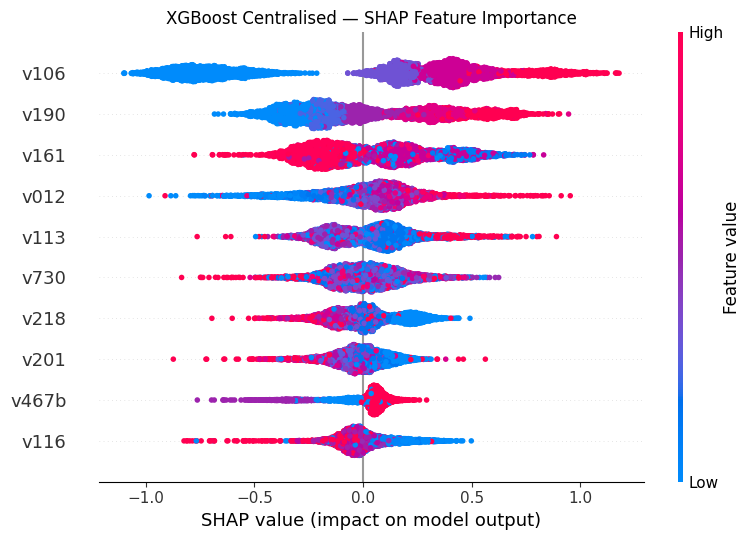

SHAP plot saved


In [45]:
# SHAP summary plot

import matplotlib.pyplot as plt

os.makedirs("/kaggle/working/processed", exist_ok=True)

# XGBoost SHAP summary plot
shap.summary_plot(
    shap_values_xgb,
    X_test,
    max_display=10,
    show=False
)
plt.title("XGBoost Centralised — SHAP Feature Importance")
plt.tight_layout()
plt.savefig("/kaggle/working/processed/shap_xgb_centralised.png", dpi=150)
plt.show()
print("SHAP plot saved")

In [46]:
# Save the both models and the SHAP values
# Saves the full machine learning pipeline

import pickle

save_dir = "/kaggle/working/processed"

# Save models
with open(f"{save_dir}/lr_model.pkl", "wb") as f:
    pickle.dump(lr, f)

with open(f"{save_dir}/xgb_model.pkl", "wb") as f:
    pickle.dump(xgb, f)

# Save SHAP values and importance tables
with open(f"{save_dir}/shap_values_xgb.pkl", "wb") as f:
    pickle.dump(shap_values_xgb, f)

with open(f"{save_dir}/shap_values_lr.pkl", "wb") as f:
    pickle.dump(shap_values_lr, f)

shap_importance.to_parquet(f"{save_dir}/shap_importance_xgb.parquet", index=False)
shap_importance_lr.to_parquet(f"{save_dir}/shap_importance_lr.parquet", index=False)

# Save feature column list — needed for federated simulation
feature_cols = list(X_train.columns)
with open(f"{save_dir}/feature_cols.pkl", "wb") as f:
    pickle.dump(feature_cols, f)

print("Saved files:")
for fname in os.listdir(save_dir):
    fpath = os.path.join(save_dir, fname)
    print(f"  {fname:<45} {os.path.getsize(fpath)/1e6:.2f} MB")

Saved files:
  shap_xgb_centralised.png                      0.20 MB
  feature_cols.pkl                              0.00 MB
  global_test.parquet                           0.09 MB
  shap_importance_xgb.parquet                   0.00 MB
  shap_values_xgb.pkl                           0.29 MB
  shap_values_lr.pkl                            0.58 MB
  lr_model.pkl                                  0.00 MB
  global_train.parquet                          0.26 MB
  shap_importance_lr.parquet                    0.00 MB
  xgb_model.pkl                                 0.78 MB
  client_partition_summary.png                  0.08 MB
  client_splits.pkl                             4.11 MB


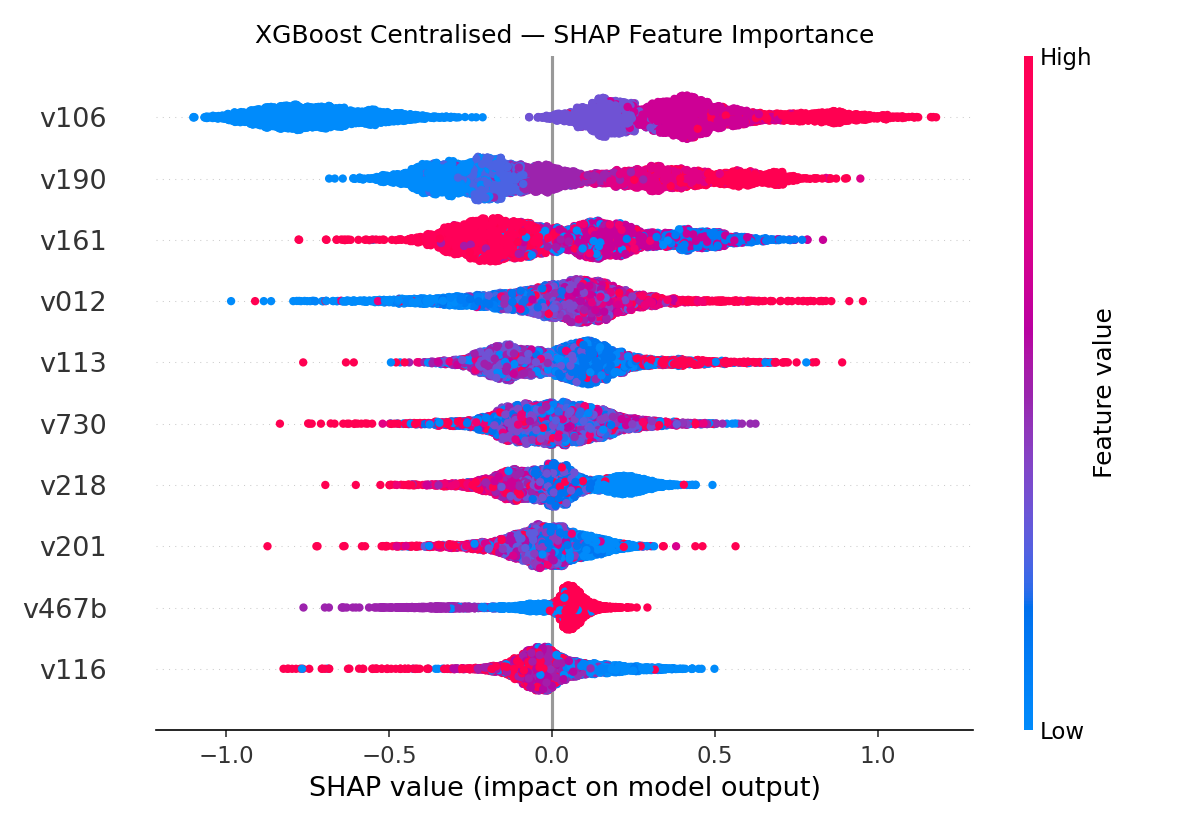

In [48]:
# Display the image directly in the notebook
# Confirming the image was saved

from IPython.display import Image
Image("/kaggle/working/processed/shap_xgb_centralised.png")